# NBA Players stats(2023 season)
### 2022-2023的 82 場例行賽
[點我看網站](https://www.kaggle.com/datasets/amirhosseinmirzaie/nba-players-stats2023-season)

## Position與進攻、防守的關係
- 

In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [214]:
origin = pd.read_csv('2023_nba_player_stats.csv')
data = pd.read_csv('2023nba.csv')

In [215]:
origin.head()

,PName,POS,Team,Age,GP,W,L,Min,PTS,FGM,...,REB,AST,TOV,STL,BLK,PF,FP,DD2,TD3,+/-
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,649,342,213,78,51,160,3691,31,1,470
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,670,274,226,66,112,205,3706,39,1,424
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,569,529,236,90,33,166,3747,36,10,128
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,329,371,192,112,65,192,3425,3,0,149
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,742,359,246,52,51,197,3451,46,6,341


In [216]:
data.head()

,PName,POS,Team,Age,GP,W,L,Min,PTS,FGM,...,TD3,Plus/Minus,PPG,RPG,APG,TOPG,SPG,BPG,FPG,TS%
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,1,470,30.07,8.77,4.62,2.88,1.05,0.69,2.16,60.70
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,1,424,33.08,10.15,4.15,3.42,1.00,1.70,3.11,65.47
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,10,128,32.39,8.62,8.02,3.58,1.36,0.50,2.52,60.93
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,0,149,31.40,4.84,5.46,2.82,1.65,0.96,2.82,62.57
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,6,341,31.10,11.78,5.70,3.90,0.83,0.81,3.13,60.55


| G | SG | PG | F | SF | PF | C |
|----|---|----|----|----|---|---|
| Guard | Shooting_Guard | Point_Guard | Forward | Small_Forward | Power_Forward | Center |
| 後衛 | 得分後衛 | 控球後衛 | 前鋒 | 小前鋒 | 大前鋒 | 中鋒 |

In [217]:
data.rename(columns={
    'PName': 'Player_Name',
    'POS': 'Position',
    'Team': 'Team_Abbreviation',
    'Age': 'Age',
    'GP': 'Games_Played',
    'W': 'Wins',
    'L': 'Losses',
    'Min': 'Minutes_Played',
    'PTS': 'Total_Points',
    'FGM': 'Field_Goal_Made',
    'FGA': 'Field_Goal_Attempted',
    'FG%': 'Field_Goal_Percentage',
    '3PM': 'Three_Point_Made',
    '3PA': 'Three_Point_Attempted',
    '3P%': 'Three_Point_Percentage',
    'FTM': 'Free_Throw_Made',
    'FTA': 'Free_Throw_Attempted',
    'FT%': 'Free_Throw_Percentage',
    'OREB': 'Offensive_Rebounds',
    'DREB': 'Defensive_Rebounds',
    'REB': 'Total_Rebounds',
    'AST': 'Assists',
    'TOV': 'Turnovers',
    'STL': 'Steals',
    'BLK': 'Blocks',
    'PF': 'Personal_Fouls',
    'FP': 'NBA_Fantasy_Points',
    'DD2': 'Double_Doubles',
    'TD3': 'Triple_Doubles',
    '+/-': 'Plus_Minus',
    'PPG': 'Points_Per_Game',
    'RPG': 'Rebounds_Per_Game',
    'APG' :'Assists_Per_Game',
    'TOPG' :'Turnovers_Per_Game',
    'SPG' :'Steals_Per_Game',
    'BPG' :'Blocks_Per_Game',
    'FPG' :'Fouls_Per_Game',
    'TS%' :'True_Shooting_Percentage'
}, inplace=True)

| 原始欄位 | 英文說明欄位 | 中文解釋 |
|---------|--------------|----------|
| PName   | Player_Name | 球員姓名 |
| POS     | Position | 場上位置 |
| Team    | Team_Abbreviation | 球隊縮寫 |
| Age     | Age | 年齡 |
| GP      | Games_Played | 出賽場次 |
| W       | Wins | 勝場 |
| L       | Losses | 敗場 |
| Min     | Minutes_Played | 上場時間（分鐘） |
| PTS     | Total_Points | 總得分 |
| FGM     | Field_Goal_Made | 投籃命中數 |
| FGA     | Field_Goal_Attempted | 投籃出手數 |
| FG%     | Field_Goal_Percentage | 投籃命中率 |
| 3PM     | Three_Point_Made | 三分命中數 |
| 3PA     | Three_Point_Attempted | 三分出手數 |
| 3P%     | Three_Point_Percentage | 三分命中率 |
| FTM     | Free_Throw_Made | 罰球命中數 |
| FTA     | Free_Throw_Attempted | 罰球出手數 |
| FT%     | Free_Throw_Percentage | 罰球命中率 |
| OREB    | Offensive_Rebounds | 進攻籃板 |
| DREB    | Defensive_Rebounds | 防守籃板 |
| REB     | Total_Rebounds | 總籃板 |
| AST     | Assists | 助攻 |
| TOV     | Turnovers | 失誤 |
| STL     | Steals | 抄截 |
| BLK     | Blocks | 阻攻（火鍋） |
| PF      | Personal_Fouls | 犯規 |
| FP      | NBA_Fantasy_Points | NBA Fantasy 積分 |
| DD2     | Double_Doubles | 「雙十」次數 |
| TD3     | Triple_Doubles | 「大三元」次數 |
| +/-     | Plus_Minus | 場上正負值 |
| PPG     | Points Per Game | 場均得分 |
| RPG     | Rebounds Per Game | 場均籃板 |
| APG     | Assists Per Game | 場均助攻 |
| TOPG    | Turnovers Per Game | 場均失誤 |
| SPG     | Steals Per Game | 場均抄截 |
| BPG     | Blocks Per Game | 場均蓋冒 | 
| FPG     | Fouls Per Game | 場均犯規 |
| TS%     | True Shooting Percentage | 真實命中率 | 

### How to calculate the fantasy points
- Three Point Field Goals: 3 points
- Two Point Field Goals: 2 points
- Free Throws Made: 1 point
- Rebounds: 1.2 points
- Assists: 1.5 points
- Blocked Shots: 2 points
- Steals: 2 points
- Turnovers: -1 points


In [218]:
data.head()

,Player_Name,Position,Team_Abbreviation,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,...,Triple_Doubles,Plus/Minus,Points_Per_Game,Rebounds_Per_Game,Assists_Per_Game,Turnovers_Per_Game,Steals_Per_Game,Blocks_Per_Game,Fouls_Per_Game,True_Shooting_Percentage
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,1,470,30.07,8.77,4.62,2.88,1.05,0.69,2.16,60.70
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,1,424,33.08,10.15,4.15,3.42,1.00,1.70,3.11,65.47
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,10,128,32.39,8.62,8.02,3.58,1.36,0.50,2.52,60.93
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,0,149,31.40,4.84,5.46,2.82,1.65,0.96,2.82,62.57
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,6,341,31.10,11.78,5.70,3.90,0.83,0.81,3.13,60.55


In [219]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Player_Name               539 non-null    object 
 1   Position                  539 non-null    object 
 2   Team_Abbreviation         539 non-null    object 
 3   Age                       539 non-null    int64  
 4   Games_Played              539 non-null    int64  
 5   Wins                      539 non-null    int64  
 6   Losses                    539 non-null    int64  
 7   Minutes_Played            539 non-null    float64
 8   Total_Points              539 non-null    int64  
 9   Field_Goal_Made           539 non-null    int64  
 10  Field_Goal_Attempted      539 non-null    int64  
 11  Field_Goal_Percentage     539 non-null    float64
 12  Three_Point_Made          539 non-null    int64  
 13  Three_Point_Attempted     539 non-null    int64  
 14  Three_Poin

In [220]:
data['True_Shooting_Percentage'] = pd.to_numeric(data['True_Shooting_Percentage'], errors='coerce')
data['True_Shooting_Percentage'] = data['True_Shooting_Percentage'].fillna(0)

In [221]:
data['Offensive_Rebounds_Per_Game'] = (data['Offensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0)
data.loc[data['Games_Played'] == 0, 'Offensive_Rebounds_Per_Game'] = 0
data['Defensive_Rebounds_Per_Game'] = (data['Defensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0)
data.loc[data['Games_Played'] == 0, 'Defensive_Rebounds_Per_Game'] = 0

In [222]:
data.duplicated().sum()

0

In [223]:
data.isna().sum()

Player_Name                    0
Position                       0
Team_Abbreviation              0
Age                            0
Games_Played                   0
Wins                           0
Losses                         0
Minutes_Played                 0
Total_Points                   0
Field_Goal_Made                0
Field_Goal_Attempted           0
Field_Goal_Percentage          0
Three_Point_Made               0
Three_Point_Attempted          0
Three_Point_Percentage         0
Free_Throw_Made                0
Free_Throw_Attempted           0
Free_Throw_Percentage          0
Offensive_Rebounds             0
Defensive_Rebounds             0
Total_Rebounds                 0
Assists                        0
Turnovers                      0
Steals                         0
Blocks                         0
Personal_Fouls                 0
NBA_Fantasy_Points             0
Double_Doubles                 0
Triple_Doubles                 0
Plus/Minus                     0
Points_Per

In [224]:
data["Two_Point_Made"] = data["Field_Goal_Made"]-data["Three_Point_Made"]
data["Two_Point_Attempted"] = data["Field_Goal_Attempted"]-data["Three_Point_Attempted"]
data["Two_Point_Percentage"] = (data["Two_Point_Made"]/data["Two_Point_Attempted"]).where(data["Two_Point_Attempted"]>0)
data.loc[data['Two_Point_Attempted'] == 0, 'Two_Point_Percentage'] = 0

In [225]:
data['Average_wins'] = data['Wins'] / data['Games_Played']

In [226]:
data['Average_Minutes_Played'] = data['Minutes_Played'] / data['Games_Played']

In [227]:
data.describe()

,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,Field_Goal_Attempted,Field_Goal_Percentage,Three_Point_Made,...,Blocks_Per_Game,Fouls_Per_Game,True_Shooting_Percentage,Offensive_Rebounds_Per_Game,Defensive_Rebounds_Per_Game,Two_Point_Made,Two_Point_Attempted,Two_Point_Percentage,Average_wins,Average_Minutes_Played
count,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,...,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000
mean,25.970315,48.040816,24.018553,24.022263,1103.617625,523.426716,191.576994,403.005566,46.325232,56.324675,...,0.380093,1.688757,56.059276,0.866534,2.674356,135.252319,246.857143,0.529881,0.486446,19.796567
std,4.315513,24.650686,14.496366,13.445866,827.765114,498.084360,178.351286,369.595909,10.967271,60.916821,...,0.384011,0.791694,10.305378,0.747214,1.774936,139.834060,251.318678,0.140293,0.170035,9.541295
min,19.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,23.000000,30.500000,12.000000,14.000000,329.000000,120.500000,45.500000,93.500000,41.650000,5.000000,...,0.140000,1.175000,52.350000,0.336022,1.385856,25.000000,45.500000,0.485330,0.408249,12.452484
50%,25.000000,54.000000,25.000000,25.000000,970.200000,374.000000,138.000000,300.000000,45.500000,36.000000,...,0.270000,1.650000,56.700000,0.677419,2.298507,86.000000,163.000000,0.535928,0.500000,19.185185
75%,29.000000,68.000000,36.000000,34.000000,1845.900000,769.500000,283.500000,598.500000,50.600000,92.000000,...,0.495000,2.205000,60.925000,1.144599,3.524038,204.000000,365.000000,0.594067,0.585786,28.346682
max,42.000000,83.000000,57.000000,60.000000,2963.200000,2225.000000,728.000000,1559.000000,100.000000,301.000000,...,3.000000,5.000000,106.380000,5.095238,9.603175,662.000000,1213.000000,1.000000,1.000000,40.800000


In [228]:
data.columns

Index(['Player_Name', 'Position', 'Team_Abbreviation', 'Age', 'Games_Played',
       'Wins', 'Losses', 'Minutes_Played', 'Total_Points', 'Field_Goal_Made',
       'Field_Goal_Attempted', 'Field_Goal_Percentage', 'Three_Point_Made',
       'Three_Point_Attempted', 'Three_Point_Percentage', 'Free_Throw_Made',
       'Free_Throw_Attempted', 'Free_Throw_Percentage', 'Offensive_Rebounds',
       'Defensive_Rebounds', 'Total_Rebounds', 'Assists', 'Turnovers',
       'Steals', 'Blocks', 'Personal_Fouls', 'NBA_Fantasy_Points',
       'Double_Doubles', 'Triple_Doubles', 'Plus/Minus', 'Points_Per_Game',
       'Rebounds_Per_Game', 'Assists_Per_Game', 'Turnovers_Per_Game',
       'Steals_Per_Game', 'Blocks_Per_Game', 'Fouls_Per_Game',
       'True_Shooting_Percentage', 'Offensive_Rebounds_Per_Game',
       'Defensive_Rebounds_Per_Game', 'Two_Point_Made', 'Two_Point_Attempted',
       'Two_Point_Percentage', 'Average_wins', 'Average_Minutes_Played'],
      dtype='object')

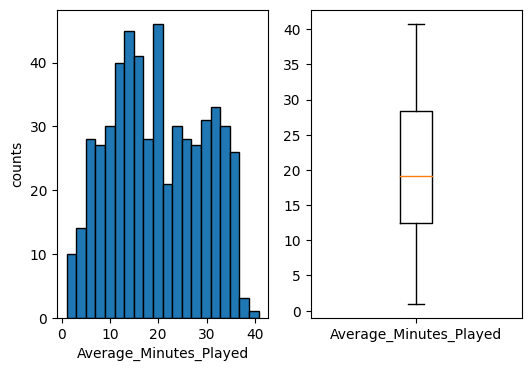

In [229]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax = ax.flatten()
ax[0].hist(data['Average_Minutes_Played'], bins=20, edgecolor='k')
ax[0].set_xlabel('Average_Minutes_Played')
ax[0].set_ylabel('counts')

ax[1].boxplot(data['Average_Minutes_Played'], labels=['Average_Minutes_Played'])

plt.show()

In [230]:
df = data[data['Average_Minutes_Played'] > 19].reset_index(drop=True)
df.shape

(275, 45)

In [231]:
df

,Player_Name,Position,Team_Abbreviation,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,...,Blocks_Per_Game,Fouls_Per_Game,True_Shooting_Percentage,Offensive_Rebounds_Per_Game,Defensive_Rebounds_Per_Game,Two_Point_Made,Two_Point_Attempted,Two_Point_Percentage,Average_wins,Average_Minutes_Played
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,0.69,2.16,60.70,1.054054,7.716216,487,873,0.557847,0.702703,36.921622
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,1.70,3.11,65.47,1.712121,8.439394,662,1128,0.586879,0.651515,34.607576
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,0.50,2.52,60.93,0.818182,7.803030,534,908,0.588106,0.500000,36.219697
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,0.96,2.82,62.57,0.867647,3.970588,646,1213,0.532564,0.485294,35.529412
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,0.81,3.13,60.55,2.174603,9.603175,660,1107,0.596206,0.746032,32.120635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,Louis King,SF,PHI,24,1,1,0,28.8,20,8,...,0.00,4.00,74.40,2.000000,2.000000,4,5,0.800000,1.000000,28.800000
271,Justin Minaya,F,POR,24,4,0,4,88.8,17,7,...,1.25,2.25,36.26,0.750000,3.000000,4,11,0.363636,0.000000,22.200000
272,RaiQuan Gray,F,BKN,23,1,0,1,35.1,16,6,...,1.00,5.00,62.11,3.000000,6.000000,4,7,0.571429,0.000000,35.100000
273,Chance Comanche,C,POR,27,1,0,1,20.8,7,3,...,1.00,0.00,51.78,2.000000,1.000000,3,5,0.600000,0.000000,20.800000


In [232]:
df.replace({'Position': {'PG': 'G', 'SG': 'G', 'SF': 'F', 'PF': 'F'}}, inplace=True)

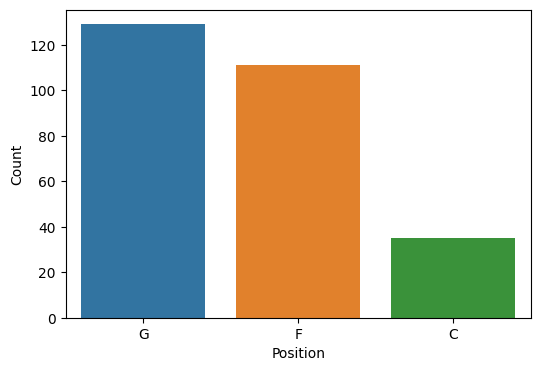

In [233]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

plt.figure(figsize=(6, 4))
sns.barplot(data=position_counts, x='Position', y='Count', hue='Position')
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

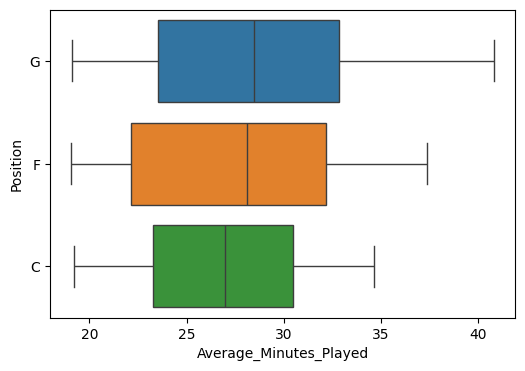

In [234]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Average_Minutes_Played', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'])
plt.show()

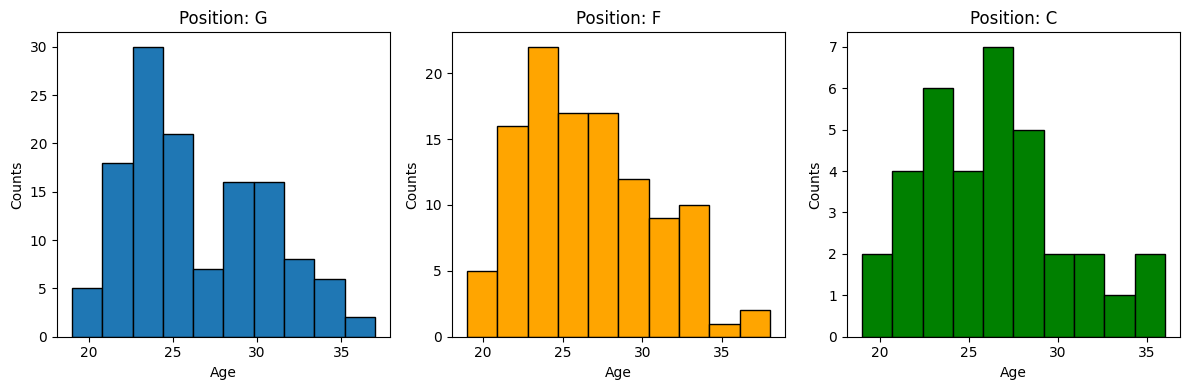

In [235]:
positions=['G', 'F', 'C']
colors = {'G': None, 'F': 'orange', 'C': 'green'}

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs = axs.flatten()

for i, p in enumerate(positions):
    ax = axs[i]
    sub = df[df['Position'] == p] 
    ax.hist(x=sub['Age'], color=colors[p], edgecolor='k')
    ax.set_title(f'Position: {p}')
    ax.set_xlabel('Age')
    ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_25500\3434416789.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  per_df.rename(columns={


<Figure size 1000x1000 with 0 Axes>

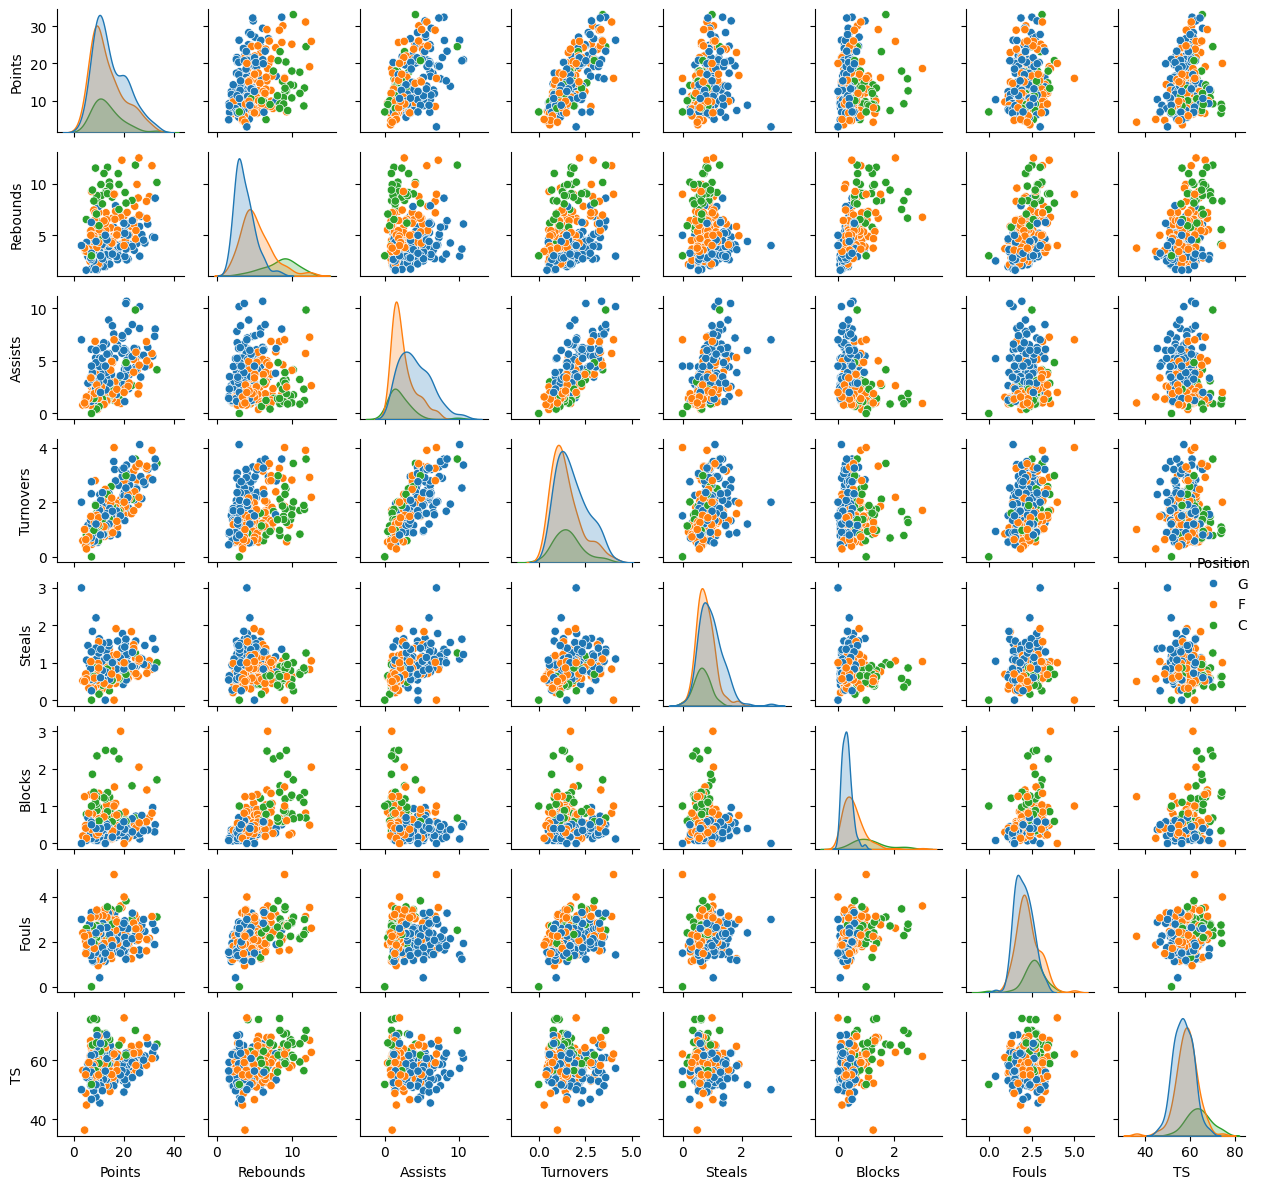

In [236]:
per_df = df[['Position', 'Points_Per_Game', 'Rebounds_Per_Game', 'Assists_Per_Game', 'Turnovers_Per_Game',
                'Steals_Per_Game', 'Blocks_Per_Game', 'Fouls_Per_Game', 'True_Shooting_Percentage']]
per_df.rename(columns={
    'Points_Per_Game': 'Points',
    'Rebounds_Per_Game': 'Rebounds',
    'Assists_Per_Game': 'Assists',
    'Turnovers_Per_Game': 'Turnovers',
    'Steals_Per_Game': 'Steals',
    'Blocks_Per_Game': 'Blocks', 
    'Fouls_Per_Game': 'Fouls', 
    'True_Shooting_Percentage': 'TS'}, inplace=True)
plt.figure(figsize=(10, 10))
sns.pairplot(per_df, hue='Position', hue_order=['G', 'F', 'C'], height=1.5)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_25500\2996409192.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Attack_df.rename(columns={


<Figure size 1000x1000 with 0 Axes>

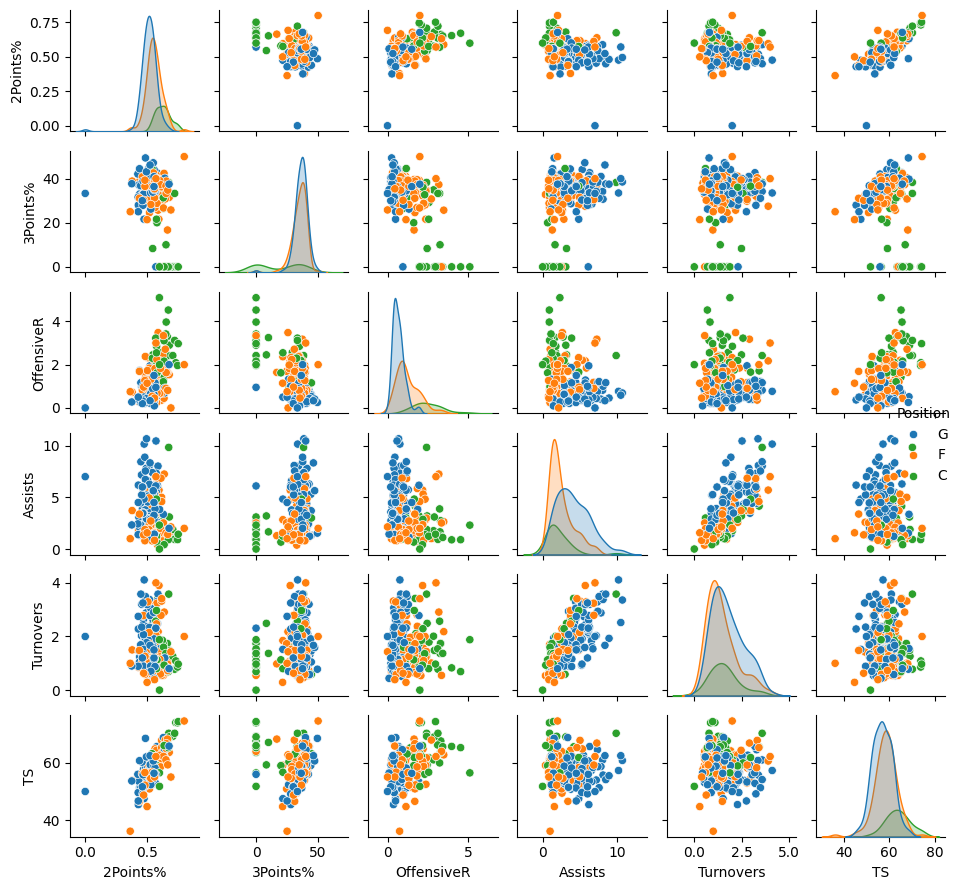

In [237]:
Attack_df = df[['Position', 'Two_Point_Percentage', 'Three_Point_Percentage', 'Offensive_Rebounds_Per_Game',
                'Assists_Per_Game', 'Turnovers_Per_Game', 'True_Shooting_Percentage']]
Attack_df.rename(columns={
    'Two_Point_Percentage': '2Points%',
    'Three_Point_Percentage': '3Points%',
    'Assists_Per_Game': 'Assists',
    'Turnovers_Per_Game': 'Turnovers',
    'Offensive_Rebounds_Per_Game': 'OffensiveR', 
    'True_Shooting_Percentage': 'TS'}, inplace=True)
plt.figure(figsize=(10, 10))
sns.pairplot(Attack_df, hue='Position', hue_order=['G', 'F', 'C'], height=1.5)
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_25500\783144736.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Defence_df.rename(columns={


<Figure size 1000x1000 with 0 Axes>

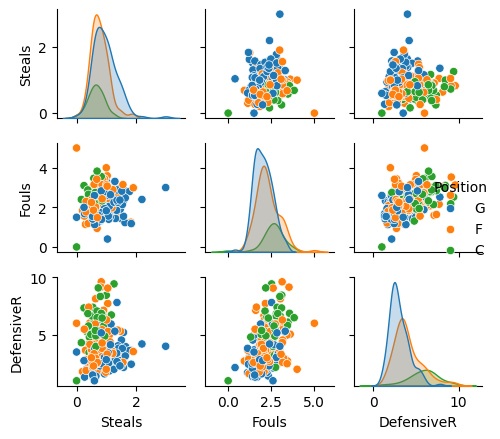

In [238]:
Defence_df = df[['Position', 'Steals_Per_Game', 'Fouls_Per_Game',
                'Defensive_Rebounds_Per_Game']]
Defence_df.rename(columns={
    'Steals_Per_Game': 'Steals',
    'Fouls_Per_Game': 'Fouls',
    'Defensive_Rebounds_Per_Game': 'DefensiveR'}, inplace=True)
plt.figure(figsize=(10, 10))
sns.pairplot(Defence_df, hue='Position', hue_order=['G', 'F', 'C'], height=1.5)
plt.tight_layout()
plt.show()

<Axes: xlabel='Two_Point_Made', ylabel='Three_Point_Made'>

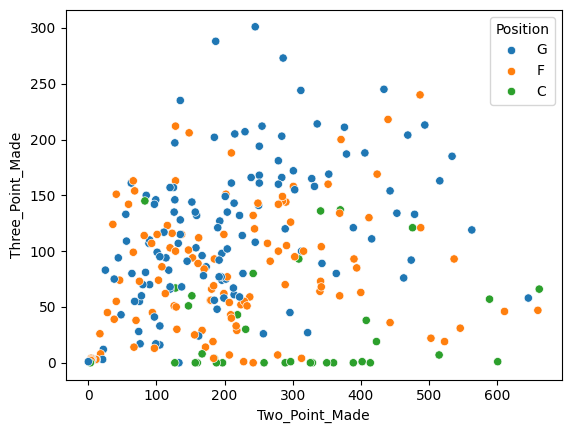

In [239]:
sns.scatterplot(x=df['Two_Point_Made'], y=df['Three_Point_Made'], hue=df['Position'], hue_order=['G', 'F', 'C'])

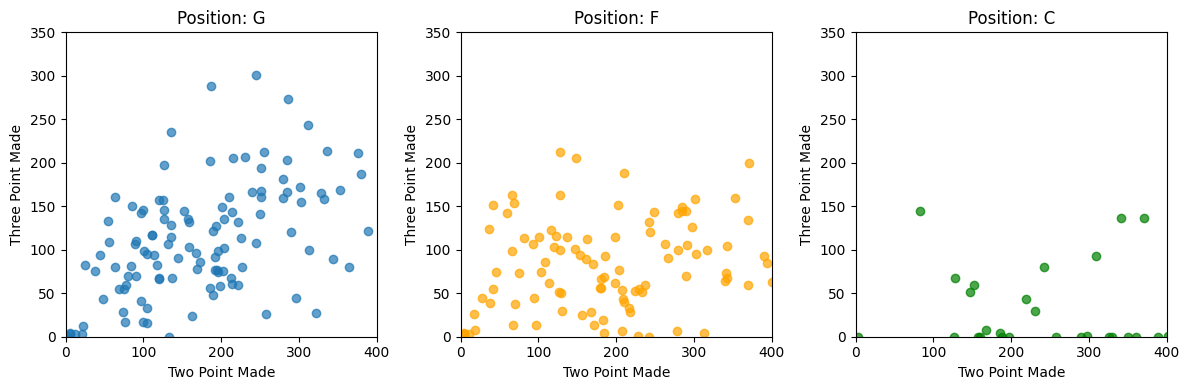

In [240]:
positions=['G', 'F', 'C']
colors = {'G': None, 'F': 'orange', 'C': 'green'}

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs = axs.flatten()

for i, p in enumerate(positions):
    ax = axs[i]
    sub = df[df['Position'] == p] 
    ax.scatter(x=sub['Two_Point_Made'], y=sub['Three_Point_Made'], alpha=0.7, color=colors[p])
    ax.set_title(f'Position: {p}')
    ax.set_xlabel('Two Point Made')
    ax.set_ylabel('Three Point Made')
    ax.set_xlim(0, 400)
    ax.set_ylim(0, 350)

plt.tight_layout()
plt.show()

In [241]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

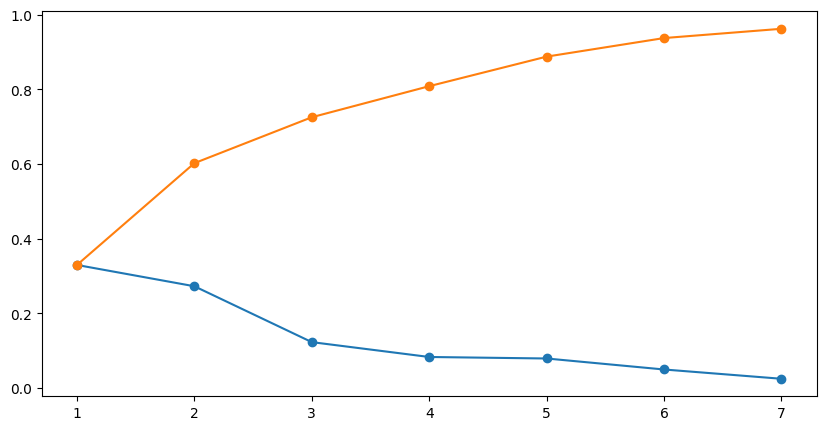

In [248]:
Above_df = df[['Position', 'Two_Point_Percentage', 'Three_Point_Percentage', 'Offensive_Rebounds_Per_Game',
                'Assists_Per_Game', 'Turnovers_Per_Game', 'True_Shooting_Percentage', 'Steals_Per_Game', 'Fouls_Per_Game',
                'Defensive_Rebounds_Per_Game']]

scaler = StandardScaler()
Above_df_scaled = scaler.fit_transform(Above_df.drop(columns=['Position']))
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(Above_df_scaled)
# pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])

explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', label='explined variance')
plt.plot(range(1, len(cum_explained_variance)+1), cum_explained_variance, marker='o', label='cumulative explained variance')
plt.show()

<Axes: >

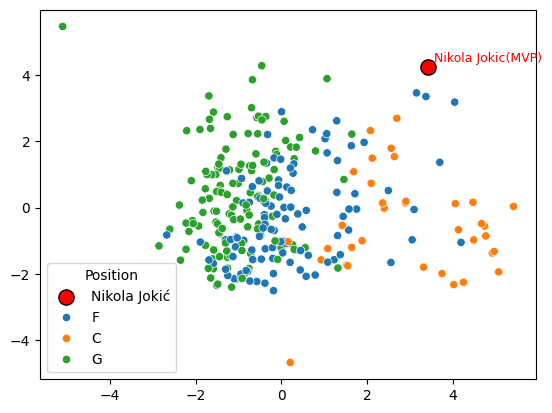

In [249]:
jokic_idx = df.index[df["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=Above_df['Position'])

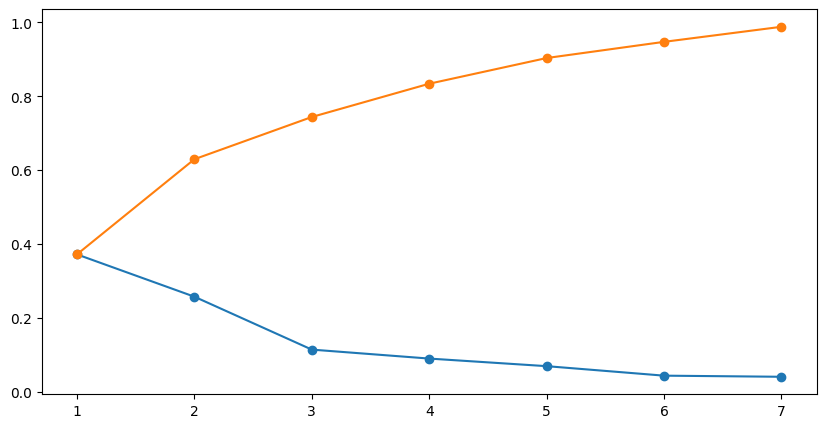

In [245]:
scaler = StandardScaler()
per_df_scaled = scaler.fit_transform(per_df.drop(columns=['Position']))
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(per_df_scaled)
# pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])

explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', label='explined variance')
plt.plot(range(1, len(cum_explained_variance)+1), cum_explained_variance, marker='o', label='cumulative explained variance')
plt.show()

<Axes: >

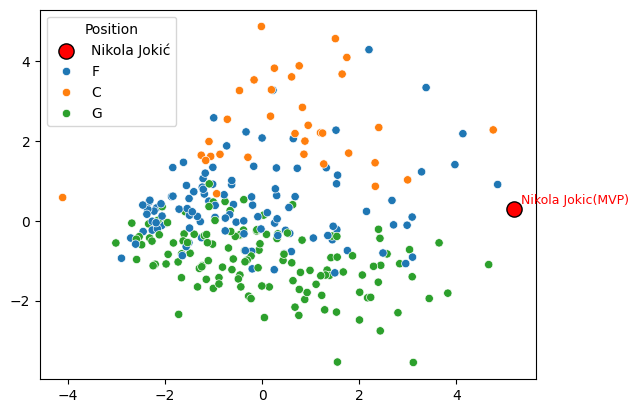

In [246]:
jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=per_df['Position'])